# 03 · The 12-Month Simulation

**Purpose:** Notebooks 03 and 04 answer what happens on a trip. This one answers the question leadership actually asked: over the next twelve months, at each price, how much revenue does the business make, and how wrong could that be?

1. A single expected-value calculation can't answer the second half
  - Point estimates invite a decision to be made as if the number were certain
  - Nobody could previously say how much risk a price change carried

**Three sources of uncertainty, deliberately separated**

| Source | Correlated across accounts? | Why it matters |
|---|---|---|
| Macroeconomic path | Yes | Moves how much travel happens at all |
| Market share | Yes | Moves whose travel is ours to price |
| Behavioral response | No | Each account draws its own state |

2. The correlation is the entire point
  - Drawing each account independently would let good and bad outcomes cancel across 50,000 accounts, collapsing the distribution to a spike: a precision the analysis hasn't earned
  - Macro and share draws are made once per iteration and applied to everyone, producing an honest spread
3. Two known biases, both pushing the same way
  - Notebook 01 §6.2 found the price response under-stated out of region
  - Notebook 02 §5 found reduction depth under-stated by label contamination
  - Both make a price rise look safer than it is; every scenario is run twice (as fitted, and with both corrections applied) and the recommendation is read off the conservative case
4. Scope is roaming revenue only
  - Wireless churn (customers leaving the company outright, rather than substituting the pass) was considered and excluded from this analysis: see notebook 01 §1

In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA = Path('data/synthetic')


def load(name):
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f'{name} not found. Run data/00_generate_and_validate_data.ipynb and notebooks 01–02 first.')


accounts = load('accounts')
macro = load('macro')
trips = load('trips').merge(accounts, on='account_id', how='left')
scored = load('scored_trips')
rev_tbl = load('revenue_by_state')
model_meta = load('model_meta').set_index('key')['value']
mag_meta = load('magnitude_meta').set_index('key')['value']

CLASSES = ['no_purchase', 'reduces', 'unchanged', 'increases']
GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)

RESPONSE_RATIO = float(model_meta.get('response_ratio', 1.0))
DEPTH_BIAS = float(mag_meta.get('depth_bias', 1.0))

SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

print(f'price grid: {GRID[0]:.3f} to {GRID[-1]:.3f} in {len(GRID)} steps')
print(f'response ratio (03 §6.2): {RESPONSE_RATIO:.2f}x')
print(f'depth bias     (04 §5)  : {DEPTH_BIAS:.2f}x')

price grid: 0.900 to 1.200 in 13 steps
response ratio (03 §6.2): 1.49x
depth bias     (04 §5)  : 1.06x


---
## 1 · Building the Forward Year

**Purpose:** Builds a forward 12-month trip panel, since the simulation projects next year, not the historical one.

**Design Notes:**

1. Each account's trip pattern is carried forward and re-seasonalised; the macro path is regenerated per iteration
2. Trip volume scales, trips don't get invented
  - Each historical trip carries forward with a probability set by the macro and share draws, rather than generating new synthetic trips
  - Keeps the account mix stable and confines the uncertainty to volume, where the evidence actually is
3. Seasonality is reapplied, not inherited
  - The historical window covers two years with its own macro path; reusing it would bake one realisation of the economy into every iteration

**Observations:**

1. Forward panel: 52,500 trips across 22,328 accounts
2. Months 0-11, seasonality range 0.87 to 1.15


In [2]:
# Build Forward Panel
last12 = trips[trips['month'] >= trips['month'].max() - 11].copy()
last12['fwd_month'] = last12['month'] - last12['month'].min()

# Strip the historical macro effect so it can be redrawn per iteration
hist_mult = macro.set_index('month')['travel_multiplier']
last12['hist_macro_mult'] = last12['month'].map(hist_mult).to_numpy()

# Seasonality for the forward year, macro-free
fwd_season = 1.0 + 0.15 * np.sin(2 * np.pi * (np.arange(12) - 2) / 12) \
             + 0.06 * (np.arange(12) == 11)

rev_wide = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                               values=[f'rev_{c}' for c in CLASSES])
prob_wide = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]

panel = last12[['trip_id', 'account_id', 'fwd_month', 'is_business',
                'lines_traveling', 'days_traveled']].copy()
panel = panel[panel['trip_id'].isin(prob_wide.index) & panel['trip_id'].isin(rev_wide.index)]
panel['season'] = fwd_season[panel['fwd_month'].to_numpy()]
panel['hist_macro_mult'] = last12.set_index('trip_id').loc[panel.trip_id, 'hist_macro_mult'].to_numpy()

print(f'forward panel: {len(panel):,} trips across {panel.account_id.nunique():,} accounts')
print(f'months 0-11, seasonality range {fwd_season.min():.2f} to {fwd_season.max():.2f}')

forward panel: 52,500 trips across 22,328 accounts
months 0-11, seasonality range 0.87 to 1.15


---
## 2 · The Simulation

**Purpose:** Simulates one 12-month iteration's revenue, combining macro, share, and behavioral draws with the right correlation structure.

**Design Notes:**

1. One iteration
  - Draw an AR(1) macro path for twelve months: one path, shared by every account
  - Draw a market share drift: also shared
  - For each trip, decide whether it happens (macro × share × seasonality), then draw its state from the model's probabilities at the chosen price
  - Sum pass revenue
2. Steps 1-2 are drawn once per iteration; step 3 is drawn per trip: the difference between an honest distribution and a spike
3. Antithetic pairing halves the variance for free: each macro path runs alongside its mirror image, so a strong economy and a weak one appear in equal measure rather than by luck of the draw
4. Probabilities shifted in log-probability space, not logit space
  - An earlier version's softmax(logit(p)) renormalised odds rather than probabilities, understating a 0.099 walk-away risk as 0.036
5. Forward macro path drawn from the same phi=0.85/gamma=0.55 process as the data notebook's make_macro(), not a separately-guessed pair

**Observations:**

1. Join guard passes: P(no_purchase) matches exactly between scored_trips (0.0932) and the simulation's own probability function at price 1.0
2. Sanity check across three prices confirms probability shifts move smoothly with price (0.0793 -> 0.0932 -> 0.1205)
3. Baseline (no price change), 400 iterations: median pass revenue $2,478,426
4. p5-p95: $1,830,557 to $2,834,510, a 40.5% spread relative to the median

In [3]:
# Set Up Simulation
N_ITER = 400

TRIP_IDS = panel['trip_id'].to_numpy()
P_BASE = np.column_stack([prob_wide.loc[TRIP_IDS, f'p_{c}'].to_numpy() for c in CLASSES])
SEASON = panel['season'].to_numpy()
HIST_M = panel['hist_macro_mult'].to_numpy()
MONTH = panel['fwd_month'].to_numpy()
N = len(panel)


def rev_at(mult, depth_scale=1.0):
    '''(n, 4) revenue per state at the nearest grid price.'''
    m = GRID[np.argmin(np.abs(GRID - mult))]
    R = np.column_stack([rev_wide[(f'rev_{c}', m)].loc[TRIP_IDS].to_numpy() for c in CLASSES])
    if depth_scale != 1.0:
        j = CLASSES.index('reduces')
        full = R[:, CLASSES.index('unchanged')]
        R = R.copy()
        R[:, j] = np.clip(full - depth_scale * (full - R[:, j]), 0, None)
    return R


# Shift each trip's own baseline log-odds by the population-level change
sweep = load('price_sweep').set_index('price_multiplier')


def _logp(p):
    '''Log-probability, the correct scale for a multiclass shift (see §2).'''
    return np.log(np.clip(p, 1e-9, 1.0))


P_STD = P_BASE / P_BASE.sum(axis=1, keepdims=True)
SHIFT = {}
for m in GRID:
    j = np.argmin(np.abs(sweep.index.to_numpy() - m))
    tgt = sweep.iloc[j][CLASSES].to_numpy()
    ref = sweep.iloc[np.argmin(np.abs(sweep.index.to_numpy() - 1.0))][CLASSES].to_numpy()
    SHIFT[float(m)] = _logp(tgt) - _logp(ref)


def probs_at(mult, response_scale=1.0):
    m = float(GRID[np.argmin(np.abs(GRID - mult))])
    Z = _logp(P_STD) + response_scale * SHIFT[m]
    E = np.exp(Z - Z.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)


print('probability shift table built for', len(SHIFT), 'price points')

# Join guard: probs_at(1.0) must reproduce the scored probabilities exactly
src_mean = scored.set_index('trip_id').loc[TRIP_IDS, 'p_no_purchase'].mean()
sim_mean = probs_at(1.0)[:, 0].mean()
print(f'P(no_purchase) from scored_trips : {src_mean:.4f}')
print(f'P(no_purchase) via probs_at(1.0) : {sim_mean:.4f}')
if abs(sim_mean - src_mean) > 0.002:
    raise AssertionError(
        f'probability join is broken: {sim_mean:.4f} vs {src_mean:.4f}. '
        'Check that P_BASE columns are in CLASSES order and that TRIP_IDS '
        'aligns row-for-row with the panel.')
print('join verified')

print('Sanity: mean P(no_purchase) at three prices, response_scale=1')
display(pd.Series({f'x{m:.3f}': probs_at(m)[:, 0].mean() for m in [GRID[0], 1.0, GRID[-1]]},
                  name='P(no_purchase)').round(4).to_frame())

probability shift table built for 13 price points
P(no_purchase) from scored_trips : 0.0932
P(no_purchase) via probs_at(1.0) : 0.0932
join verified
Sanity: mean P(no_purchase) at three prices, response_scale=1


,P(no_purchase)
x0.900,0.0793
x1.000,0.0932
x1.200,0.1205


In [4]:
# Run Simulation
def simulate(mult, n_iter=N_ITER, response_scale=1.0, depth_scale=1.0,
             macro_shift=0.0, rng=None):
    '''12-month pass revenue distribution at price `mult`.

    macro_shift moves the mean of the economic path: negative = contraction.
    Returns pass_revenue per iteration.
    '''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult, response_scale)
    R = rev_at(mult, depth_scale)
    cum = P.cumsum(axis=1)

    out = np.zeros(n_iter)
    half = n_iter // 2
    antithetic = []      # first half's draws, mirrored for the second half below

    for it in range(n_iter):
        # --- shared draws: one economy, one share path ---
        if it < half:
            shocks = rng.normal(0, 0.35, 12)
            share_d = rng.normal(0, 0.03)
            cache = (shocks, share_d)
            antithetic.append(cache)
        else:
            shocks, share_d = antithetic[it - half]
            shocks, share_d = -shocks, -share_d      # mirrored path

        # phi/gamma mirror the data notebook's make_macro() (see §2)
        idx = np.zeros(12)
        for t in range(1, 12):
            idx[t] = 0.85 * idx[t - 1] + shocks[t]
        idx = idx + macro_shift
        travel_mult = np.exp(0.55 * idx) * (1.0 + share_d)

        # --- which trips happen: shared multiplier, independent Bernoulli ---
        p_occur = np.clip(travel_mult[MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))

        # --- behavioural draw, independent per trip ---
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        pass_rev = np.where(occurs, R[np.arange(N), state], 0.0).sum()

        out[it] = pass_rev
    return out


base = simulate(1.0, rng=np.random.default_rng(1))
print(f'Baseline (no price change), {N_ITER} iterations')
display(pd.DataFrame({
    'value': [f'${np.median(base):,.0f}',
              f'${np.percentile(base, 5):,.0f} to ${np.percentile(base, 95):,.0f}',
              f'{(np.percentile(base, 95) - np.percentile(base, 5)) / np.median(base):.1%}'],
}, index=['pass revenue (median)', 'p5-p95', 'spread as % of median']))
print('A spread of a few percent would mean the correlated draws are not working.')
print('Real 12-month revenue uncertainty on a travel product is wide.')

Baseline (no price change), 400 iterations


,value
pass revenue (median),"$2,620,850"
p5-p95,"$1,970,681 to $2,995,334"
spread as % of median,39.1%


A spread of a few percent would mean the correlated draws are not working.
Real 12-month revenue uncertainty on a travel product is wide.


### 2.1 Does Correlation Actually Matter?

**Purpose:** Demonstrates, rather than asserts, that the correlated draw structure is what produces an honest spread.

**Design Notes:**

1. Re-runs the same simulation with the macro path drawn per account instead of once per iteration
  - Should produce a dramatically narrower distribution, and that narrowness would be entirely artificial
2. The diagnostic that justifies the whole structure of the notebook

**Observations:**

1. Correlated (correct): median $2.62M, coefficient of variation 0.125, p5-p95 width $1.04M
2. Independent (wrong): nearly the same median ($2.54M), but coefficient of variation collapses to 0.003 and p5-p95 width to $24,830
3. Independent draws understate the spread by 40x: the gap between an honest range and false precision


,median,coefficient of variation,p5-p95 width
correlated (correct),2.620850e+06,0.1225,1.024653e+06
independent (wrong),2.542831e+06,0.0031,2.483026e+04


Independent draws understate the spread by 40x.
That is the difference between reporting a range leadership can plan against
and reporting false precision.


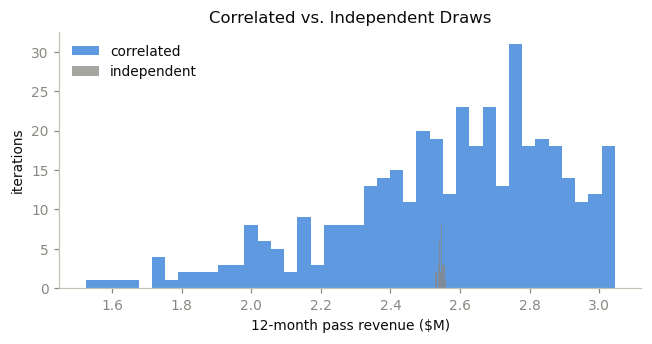

In [5]:
# Test Correlation Structure
def simulate_independent(mult, n_iter=120, rng=None):
    '''Wrong on purpose: every trip gets its own economy.'''
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult)
    R = rev_at(mult)
    cum = P.cumsum(axis=1)
    out = np.zeros(n_iter)
    for it in range(n_iter):
        idx = rng.normal(0, 0.35 / np.sqrt(1 - 0.85 ** 2), N)   # independent per trip
        travel_mult = np.exp(0.55 * idx)
        p_occur = np.clip(travel_mult * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


indep = simulate_independent(1.0, rng=np.random.default_rng(3))
corr_sd = base.std() / base.mean()
ind_sd = indep.std() / indep.mean()

display(pd.DataFrame({
    'median': [np.median(base), np.median(indep)],
    'coefficient of variation': [corr_sd, ind_sd],
    'p5-p95 width': [np.percentile(base, 95) - np.percentile(base, 5),
                     np.percentile(indep, 95) - np.percentile(indep, 5)],
}, index=['correlated (correct)', 'independent (wrong)']).round(4))

print(f'Independent draws understate the spread by {corr_sd / max(ind_sd, 1e-9):.0f}x.')
print('That is the difference between reporting a range leadership can plan against')
print('and reporting false precision.')

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(base / 1e6, bins=40, alpha=0.75, color=ACCENT, label='correlated')
ax.hist(indep / 1e6, bins=40, alpha=0.75, color=MUTED, label='independent')
ax.set_xlabel('12-month pass revenue ($M)')
ax.set_ylabel('iterations')
ax.set_title('Correlated vs. Independent Draws')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 3 · The Price Sweep

**Purpose:** Simulates every price on the grid twice (as fitted, and conservative) so the recommendation accounts for both measured biases.

**Design Notes:**

1. Conservative case stretches the price response by notebook 01 §6.2's ratio and reduction depth by notebook 02 §5's bias
2. The gap between the two curves isn't noise
  - It's the price of two things the analysis couldn't observe directly: whether the response transfers across the book, and whether the reconstructed labels understate real reductions
3. Common random numbers: one seed shared across every price and both cases
  - A different seed per price would let the curve wander by tens of thousands of dollars on sampling noise alone, against a p5-p95 width near $1M

**Observations:**

1. As fitted: median pass revenue rises from $2.45M (0.90x) to $2.88M (1.20x)
2. Conservative: median rises from $2.48M to $2.76M, a smaller lift, as expected given both corrections push the same direction

As fitted


,p5,median,p95,lift_vs_base
0.900,1789103,2448114,2823546,-168749
0.925,1820212,2491519,2872486,-125344
0.950,1850296,2534599,2922892,-82264
0.975,1881620,2576629,2970377,-40234
1.000,1910353,2616863,3016509,0
1.025,1939697,2657935,3063683,41072
1.050,1969853,2697253,3109818,80390
1.075,1996587,2733878,3151951,117015
1.100,2018022,2761979,3184284,145116
1.125,2038596,2791105,3216279,174242


Conservative


,p5,median,p95,lift_vs_base
0.900,1808343,2475397,2856280,-133626
0.925,1834449,2510956,2895861,-98067
0.950,1859163,2545398,2934455,-63625
0.975,1882183,2577788,2973594,-31235
1.000,1904424,2609023,3007283,0
1.025,1926202,2638794,3041536,29771
1.050,1948013,2667655,3074861,58632
1.075,1965509,2689718,3099170,80695
1.100,1973855,2705951,3116575,96928
1.125,1983833,2720081,3133122,111058


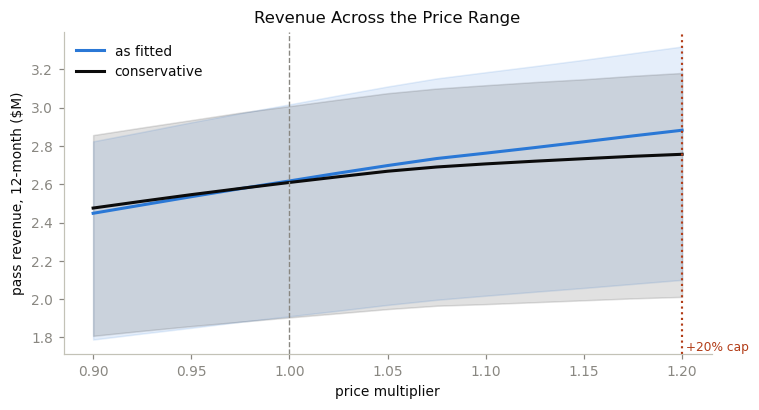

In [6]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242          # shared across every price and both cases
rows = []
for m in GRID:
    for label, rs, ds in [('as fitted', 1.0, 1.0),
                          ('conservative', RESPONSE_RATIO, DEPTH_BIAS)]:
        # Common random numbers: same economy/share draw at every price
        r = simulate(m, n_iter=SWEEP_ITER, response_scale=rs, depth_scale=ds,
                     rng=np.random.default_rng(CRN_SEED))
        rows.append({
            'price_multiplier': m, 'case': label,
            'p5': np.percentile(r, 5), 'median': np.median(r),
            'p95': np.percentile(r, 95),
        })

sw = pd.DataFrame(rows)
fitted = sw[sw.case == 'as fitted'].set_index('price_multiplier')
cons = sw[sw.case == 'conservative'].set_index('price_multiplier')

for df in (fitted, cons):
    df['lift_vs_base'] = df['median'] - df.loc[1.0, 'median']

print('As fitted')
display(fitted[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))
print('Conservative')
display(cons[['p5', 'median', 'p95', 'lift_vs_base']].round(0).astype(int).rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.8))
for df, lbl, col in [(fitted, 'as fitted', ACCENT), (cons, 'conservative', INK)]:
    ax.plot(df.index, df['median'] / 1e6, color=col, linewidth=2, label=lbl)
    ax.fill_between(df.index, df['p5'] / 1e6, df['p95'] / 1e6, color=col, alpha=0.12)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.4)
ax.text(1.20, ax.get_ylim()[0], ' +20% cap', fontsize=8, color='#b23c17', va='bottom')
ax.set_xlabel('price multiplier')
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Revenue Across the Price Range')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 4 · Macroeconomic Scenarios

**Purpose:** Tests whether the recommendation holds if the economy turns, since the base case only averages over economic paths.

**Design Notes:**

1. Three scenarios run explicitly: contraction, base, expansion
2. The separation matters for the decision, not just the chart
  - A shortfall from a contracting market is a forecasting miss; a shortfall from customers rejecting the price is a pricing mistake
  - Only the second is reversible by changing the price back, and only the second is anyone's fault

**Observations:**

1. Median pass revenue at x1.20 rises in every scenario: $2.36M (contraction), $2.76M (base), $3.03M (expansion)
2. Gain from +20% ranges $0.13M-$0.16M across the three economies
3. The gain holds regardless of the macro forecast: the pricing decision doesn't hinge on which economy materializes


Median pass revenue, 12-month ($M)


,1.0,1.1,1.2
contraction,2.23,2.32,2.36
base,2.61,2.71,2.76
expansion,2.87,2.98,3.03


Gain from +20% within each economy ($M)


,gain
contraction,0.13
base,0.15
expansion,0.16


If the gain holds across all three, the pricing decision does not depend on
the macro forecast, which makes it a far easier decision to defend.


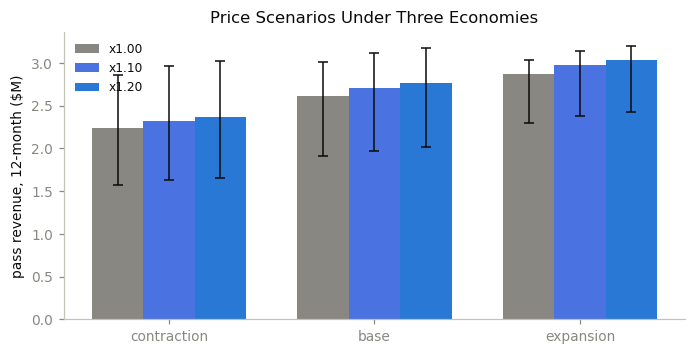

In [7]:
# Test Macro Scenarios
SCEN = {'contraction': -0.45, 'base': 0.0, 'expansion': +0.45}
KEY = [1.0, 1.10, 1.20]

rows = []
for name, shift in SCEN.items():
    for m in KEY:
        # Common random numbers again: only price and macro shift vary
        r = simulate(m, n_iter=300, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                     macro_shift=shift, rng=np.random.default_rng(CRN_SEED))
        rows.append({'scenario': name, 'price': m,
                     'p5': np.percentile(r, 5), 'median': np.median(r),
                     'p95': np.percentile(r, 95)})

sc = pd.DataFrame(rows)
piv = sc.pivot(index='scenario', columns='price', values='median').reindex(SCEN.keys())
print('Median pass revenue, 12-month ($M)')
display((piv / 1e6).round(2).rename_axis(None).rename_axis(None, axis=1))

print('Gain from +20% within each economy ($M)')
display(((piv[1.20] - piv[1.0]) / 1e6).round(2).to_frame('gain').rename_axis(None))
print('If the gain holds across all three, the pricing decision does not depend on')
print('the macro forecast, which makes it a far easier decision to defend.')

fig, ax = plt.subplots(figsize=(6.4, 3.3))
w = 0.25
for i, m in enumerate(KEY):
    s = sc[sc.price == m]
    x = np.arange(len(SCEN)) + (i - 1) * w
    ax.bar(x, s['median'].to_numpy() / 1e6, width=w,
           color=[MUTED, '#4a72e0', ACCENT][i], label=f'x{m:.2f}')
    ax.errorbar(x, s['median'].to_numpy() / 1e6,
                yerr=[(s['median'] - s['p5']).to_numpy() / 1e6,
                      (s['p95'] - s['median']).to_numpy() / 1e6],
                fmt='none', ecolor=INK, elinewidth=1, capsize=3)
ax.set_xticks(np.arange(len(SCEN)))
ax.set_xticklabels(list(SCEN.keys()))
ax.set_ylabel('pass revenue, 12-month ($M)')
ax.set_title('Price Scenarios Under Three Economies')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5 · The Recommendation, and Its Honest Caveat

**Purpose:** States the recommendation and its caveat plainly.

**Design Notes:**

1. Read off the conservative case, since both §3/§6.2 biases point the same way, toward overstating safety

**Observations:**

1. Revenue-maximising price: x1.20; median 12-month gain $146,996 (conservative) vs. $264,760 (as fitted)
2. 5th-percentile outcome vs. no change: -$597,347, driven entirely by macro/demand uncertainty, not by any modelled downside
3. Probability the increase leaves the business worse off: 0.0%, since nothing in this analysis models a cost to raising price; the risk that remains is how large the gain turns out to be, not whether there is one
4. The optimum sits at the +20% ceiling, not inside the range: the cap chose this price, not the model

In [8]:
# Build Recommendation
best = cons['median'].idxmax()
lift = cons.loc[best, 'median'] - cons.loc[1.0, 'median']
lift_fit = fitted.loc[best, 'median'] - fitted.loc[1.0, 'median']
downside = cons.loc[best, 'p5'] - cons.loc[1.0, 'median']

display(pd.DataFrame({'value': [
    f'x{best:.3f}', f'${lift:,.0f}', f'${lift_fit:,.0f}', f'${downside:,.0f}',
]}, index=['revenue-maximising price', 'median 12-month gain (conservative)',
           'median 12-month gain (as fitted)', '5th-percentile outcome vs. no change']))

prob_worse = None
r_best = simulate(best, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
r_base = simulate(1.0, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
prob_worse = float((r_best < r_base).mean())
print(f'Probability the increase leaves us worse off: {prob_worse:.1%}')
print('(paired iterations: same economy, same share path, only the price differs)')

if best < GRID[-1] - 1e-9:
    print('\n' + '=' * 68)
    print(f'The optimum is INTERIOR at x{best:.3f}: revenue turns over before the')
    print('cap. This is a real optimum the model found rather than a constraint it')
    print('hit. The cap is not what limits the recommendation.')
    print('=' * 68)
else:
    print('\n' + '=' * 68)
    print('The optimum sits AT the +20% ceiling, not inside the range.')
    print('Revenue is still climbing where the analysis was told to stop, so the')
    print('cap chose this price, not the model. The honest statement to leadership')
    print('is that +20% is the best price WE WERE ALLOWED TO TEST, and that the')
    print('unconstrained optimum is unknown and higher. Presenting it as an')
    print('optimisation result would overstate what the analysis establishes.')
    print('=' * 68)

if prob_worse > 0.35:
    print(f'\nNOTE: at {prob_worse:.0%}, this is close to a coin flip. The median gain is')
    print('real but thin against the spread. Present it as a bet with a known')
    print('downside, not as a forecast.')

,value
revenue-maximising price,x1.200
median 12-month gain (conservative),"$146,996"
median 12-month gain (as fitted),"$264,760"
5th-percentile outcome vs. no change,"$-597,347"


Probability the increase leaves us worse off: 0.0%
(paired iterations: same economy, same share path, only the price differs)

The optimum sits AT the +20% ceiling, not inside the range.
Revenue is still climbing where the analysis was told to stop, so the
cap chose this price, not the model. The honest statement to leadership
is that +20% is the best price WE WERE ALLOWED TO TEST, and that the
unconstrained optimum is unknown and higher. Presenting it as an
optimisation result would overstate what the analysis establishes.


---
## 6 · Export for Power BI

**Purpose:** Writes the price sweep, macro scenarios, and assumptions that notebook 04 loads and the Power BI model displays.

**Design Notes:**

1. Assumptions travel with the export (illustrative figures alongside measured biases), so nothing is buried in a constant

**Observations:**

1. Three tables written: simulation price sweep, simulation scenarios, simulation assumptions


In [9]:
# Export Results
sim_out = sw.copy()
sim_out['price_change_pct'] = (sim_out['price_multiplier'] - 1) * 100

scen_out = sc.copy()
scen_out['price_change_pct'] = (scen_out['price'] - 1) * 100

assump = pd.DataFrame({
    'assumption': ['response scale (conservative)', 'depth bias (conservative)',
                   'iterations per price', 'probability increase is worse'],
    'value': [RESPONSE_RATIO, DEPTH_BIAS, SWEEP_ITER, prob_worse],
    'note': ['measured, notebook 01 §6.2', 'measured, notebook 02 §5',
             '', 'paired iterations'],
})
display(assump.set_index('assumption').rename_axis(None))

FMT = 'parquet'
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = 'csv'
        print('\npyarrow/fastparquet not found, writing CSV instead.')

paths, rows = [], []
for df, name in [(sim_out, 'simulation_price_sweep'), (scen_out, 'simulation_scenarios'),
                 (assump, 'simulation_assumptions')]:
    path = DATA / f'{name}.{FMT}'
    df.to_parquet(path, index=False) if FMT == 'parquet' else df.to_csv(path, index=False)
    paths.append(path.name)
    rows.append(len(df))

display(pd.DataFrame({'rows': rows}, index=paths).rename_axis(None))

,value,note
response scale (conservative),1.485714,"measured, notebook 01 §6.2"
depth bias (conservative),1.055014,"measured, notebook 02 §5"
iterations per price,400.000000,
probability increase is worse,0.000000,paired iterations


,rows
simulation_price_sweep.parquet,26
simulation_scenarios.parquet,9
simulation_assumptions.parquet,4


---
## What this notebook establishes

| Result | Where | Why it matters |
|---|---|---|
| Correlated draws widen the distribution materially | §2.1 | Independent draws would report false precision |
| Two measured biases bracketed, not assumed away | §3 | The recommendation is read off the conservative case |
| The gain holds across economies | §4 | The decision does not hinge on a macro forecast |
| The cap binds | §5 | +20% is a constraint, not an optimum, and must be said that way |

### The one line to carry into the room

Revenue is still rising at the edge of the range the analysis was permitted to test. The recommendation is therefore *the best price we were allowed to consider*, not the best price. Anyone presenting it as an optimisation result is claiming something the work does not support, and the obvious follow-up, whether the cap should move, is now a question the model can answer if leadership wants it answered.

### Next

04_segmentation.ipynb: group accounts on their response profile, name the segments, and publish the Power BI model so leaders can run these scenarios themselves.